In [13]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    get_ipython().run_line_magic(
        'cd',
        '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-5'
    )
except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-5'
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-5


### Imports

In [14]:
import torch as tc
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

### Hyperparameters

In [15]:
seed = 42
tc.manual_seed(seed)
np.random.seed(seed)
device = 'cuda' if tc.cuda.is_available() else 'cpu'
print(f"Using {device}")
bar = 64*'-'

Using cuda


# Input–Output Structures

![](fig/types.png)
![](https://drive.google.com/uc?export=view&id=1Oo_ViW_i72lrFhWimsbnd-J8njGaeKyh)



In this figure we can see several common input–output mapping structures for predictive models. These categories are mainly defined by **how the model processes data over time**, rather than strictly by the raw format of the data itself.

In a **one-to-one** setting, a single input produces a single output. This corresponds to standard classification or regression tasks, such as mapping an image to a class label.

In **one-to-many**, a single input generates a sequence of outputs. A common example is **image captioning**, where one image is used to generate a sequence of words describing it.

In **many-to-one**, a sequence of inputs produces a single output. For example, in **sentiment analysis**, a model may process a sequence of words and output a single sentiment prediction.

Finally, **many-to-many** models map an input sequence to an output sequence. This appears in tasks such as **machine translation**, where a sentence in one language is converted into a sentence in another language, or **frame-level video labeling**, where each frame receives a prediction.

These categories depend on **how the data is represented and processed**. For instance, sentiment analysis can also be viewed as a one-to-one problem if the entire sentence is first encoded into a single feature vector before making a prediction.

## <u>Fundamental Recurrent Equation</u>

\begin{align}
h_t = f_W(h_{t-1}, x_t),
\quad
f_W : \mathbb{R}^{d_h} \times \mathbb{R}^{d_x} \rightarrow \mathbb{R}^{d_h},
\end{align}
where
- $x_t$ — input vector at time step $t$ (current)
- $h_t$ — hidden state at time step $t$ (current)
- $h_{t-1}$ — hidden state at time step $t-1$ (previous)
- $f_W$ — recurrent transformation parameterized by weights $W$.

In words, the hidden state is updated by applying the same transformation $f_W$ to the previous hidden state and the current input. Both the functional form and the parameters are shared across time steps.

## <u>Vanilla RNN Forward Propagation</u>

A common choice for $f_W$ in a vanilla RNN is:

\begin{align}
h_t &= \tanh\!\left(W_{hh} h_{t-1} + W_{xh} x_t + b_h\right), \\
o_t &= W_{hy} h_t + b_y, \\
y_t &= g(o_t),
\end{align}

where

- $W_{hh} \in \mathbb{R}^{d_h \times d_h}$ — recurrent (hidden-to-hidden) weight matrix
- $W_{xh} \in \mathbb{R}^{d_h \times d_x}$ — input-to-hidden weight matrix  
- $W_{hy} \in \mathbb{R}^{d_y \times d_h}$ — hidden-to-output weight matrix  

- $b_h \in \mathbb{R}^{d_h}$ — hidden bias vector  
- $b_y \in \mathbb{R}^{d_y}$ — output bias vector  

- $o_t \in \mathbb{R}^{d_y}$ — output pre-activation (logits)  
- $y_t \in \mathbb{R}^{d_y}$ — model output  

- $\tanh(\cdot)$ — element-wise nonlinearity (the activation of the hidden layer)
- $g(\cdot)$ — task-dependent output function, e.g., softmax, sigmoid, identity (the activation of the output layer).

# Computational Graph

![](fig/compgraph.png)
![](https://drive.google.com/uc?export=view&id=1-MykVkfTg3YNp6hRUTGoiCVcWQx3xX2b)

The diagram shows the recurrent computation unrolled across time steps.
At each step the same transformation $f_W$ is applied to the previous
hidden state $h_{t-1}$ and the current input $x_t$ to produce the new
hidden state $h_t$.

The parameter set is denoted collectively by $W$. In practice this
represents all learnable parameters of the model (e.g.,
$W_{hh}, W_{xh}, W_{hy}, b_h, b_y$), which are shared across every
time step of the sequence.

The initial hidden state $h_0$ is typically initialized to a zero
vector (or sometimes treated as a learnable parameter). The final
hidden state $h_T$ summarizes information from the entire input
sequence.

# <u>PyTorch Implementation</u>

We now move from the mathematical formulation to implementation. Using the built-in `nn.RNN` module is the standard, optimized and recommended way:

In [16]:
class VanillaRNN(nn.Module):
    def __init__(self, d_x: int, d_h: int, d_y: int):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=d_x,
            hidden_size=d_h,
            nonlinearity="tanh",
            batch_first=True
        )
        self.fc = nn.Linear(d_h, d_y)

    def forward(self, x: tc.Tensor, h0: tc.Tensor | None = None):
        # x: (B, T, d_x)
        out, hT = self.rnn(x, h0)   # out: (B, T, d_h), hT: (1, B, d_h)
        logits = self.fc(out)       # (B, T, d_y) for many-to-many
        return logits, hT

# <u>Custom Implementation</u>

However, if we want to make the recurrence explicit — for example, to gain more flexibility or modify the update rule — we can implement the RNN manually, mirroring how it is constructed under the hood.

When implementing such model components from scratch, it is **important to model everything faithfully**, even seemingly small details. Elements that may appear minor—because, for instance, they introduce only a very small (or no) number of additional parameters compared to the other components, such as a single bias term—can still play a very important role in how the model learns. In practice, omitting such "details" can noticeably affect optimization. For example, in this task the custom RNN **fails to learn** when even one bias term is removed, even though the change in the number of parameters is minimal in this case.

In [17]:
class RNNCell(nn.Module):
    def __init__(self, d_x: int, d_h: int):
        super().__init__()
        self.W_xh = nn.Linear(d_x, d_h, bias=True)
        self.W_hh = nn.Linear(d_h, d_h, bias=True)

    def forward(self, x_t: tc.Tensor, h_prev: tc.Tensor) -> tc.Tensor:
        # x_t: (B, d_x), h_prev: (B, d_h)
        return tc.tanh(self.W_xh(x_t) + self.W_hh(h_prev))

class ManualVanillaRNN(nn.Module):
    def __init__(self, d_x: int, d_h: int, d_y: int):
        super().__init__()
        self.d_h = d_h
        self.cell = RNNCell(d_x, d_h)
        self.readout = nn.Linear(d_h, d_y)

    def forward(self, x: tc.Tensor, h0: tc.Tensor | None = None):
        # x: (B, T, d_x)
        B, T, _ = x.shape

        if h0 is None:
            h = tc.zeros(B, self.d_h, device=x.device)
        else:
            # Note: PyTorch RNN states have shape (num_layers, B, hidden_size).
            # We use one layer in this tutorial, so we remove that dimension:
            h = h0[0]

        hs = []
        for t in range(T):
            h = self.cell(x[:, t, :], h)
            hs.append(h)

        H = tc.stack(hs, dim=1)     # (B, T, d_h)
        logits = self.readout(H)    # (B, T, d_y)
        return logits, h.unsqueeze(0)

## <u>Initialization Test</u>

The model expects an input of shape $(B, T, d_x)$, i.e., (batch size, sequence length, input dimension). The input is **not** a single vector with $d_x$ elements, but rather a sequence of $T$ vectors, each of dimension $d_x$. One sample therefore looks like:

\begin{align}
x = (x_1, x_2, \dots, x_T), \ x_t \in \mathbb{R}^{d_x}.
\end{align}

We now initialize two models (the built-in implementation and our manual one) using the same hyperparameters, and verify that they match in terms of architecture and number of trainable parameters.

Note that the original `torchsummary` package is not fully reliable for recurrent layers and may misreport or omit their parameters. Newer tools such as `torchinfo` support RNNs, although summaries can still be hard to interpret when the computation is explicitly unrolled in Python (as in our manual implementation). For this reason, we verify equivalence using direct parameter counting via `model.parameters()`, which always reflects the true set of trainable tensors:

In [18]:
# Helper function to count the number of trainable parameters:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# Hyperparameters:
d_x = 10   # input dimension
d_h = 32   # hidden dimension
d_y = 10   # output dimension
T   = 20   # sequence length
B   = 8    # batch size

# Built-in implementation (nn.RNN wrapper):
torch_model = VanillaRNN(d_x, d_h, d_y).to(device)
print(
    "Built-in nn.RNN model:\n"
    f"{torch_model}\n"
    f"Trainable parameters: {count_params(torch_model)}"
)

# Manual implementation:
print(bar)
manual_model = ManualVanillaRNN(d_x, d_h, d_y).to(device)
print(
    "Custom RNN model:\n"
    f"{manual_model}\n"
    f"Trainable parameters: {count_params(manual_model)}"
)

# Same count of parameters is a good first indicator that
# our implementation is probably correct.

Built-in nn.RNN model:
VanillaRNN(
  (rnn): RNN(10, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=10, bias=True)
)
Trainable parameters: 1738
----------------------------------------------------------------
Custom RNN model:
ManualVanillaRNN(
  (cell): RNNCell(
    (W_xh): Linear(in_features=10, out_features=32, bias=True)
    (W_hh): Linear(in_features=32, out_features=32, bias=True)
  )
  (readout): Linear(in_features=32, out_features=10, bias=True)
)
Trainable parameters: 1738


## <u>Toy Task: Delayed Key Memory (Many-to-One)</u>

We construct a simple synthetic task to test whether an RNN can **store information in its hidden state** over multiple time steps.

### Input
Each training example is a **sequence** of length $T$.  
At each time step $t$, the input is a vector $x_t \in \mathbb{R}^{d_x}$, so one sample has shape $(T, d_x)$, and a batch has shape $(B, T, d_x)$.

In our setup:
- $B = 8$ (batch size)
- $T = 20$ (sequence length)
- $d_x = 10$ (input dimension)

So the model receives inputs of shape **$(8, 20, 10)$**.

### How we build a sample
For each sequence, we randomly pick a class $c \in \{0,1,\dots,9\}$ and encode it as a one-hot vector in $\mathbb{R}^{10}$.  
We place this one-hot "key" at the beginning of the sequence (t = 0 in Python indexing), and set the remaining time steps to zeros. Afterwards, Gaussian noise is added to the sequence, slightly perturbing the key and the remaining inputs in order to make the task more difficult.

So the useful information appears early, and the rest of the sequence contains no additional clues.

### Target / Output
The target is the class index $c$ (an integer in $\{0,\dots,9\}$).  
Although our model produces outputs at every time step (shape $(B, T, d_y)$), **we only supervise the last step**:

- output dimension: $d_y = 10$ (10 classes)
- we use the last-step logits: `logits[:, -1, :]` (shape $(B, 10)$)

The task is therefore:

**"Remember which one-hot key appeared earlier in the sequence, and predict its class at the final time step."**

![](fig/manytoonernn.png)
![](https://drive.google.com/uc?export=view&id=1cm7jDgno3SiENcfL1IpVPZSkpLA-bCwi)


The delayed key memory task is formulated as a many-to-one sequence problem.
The model processes the entire input sequence and produces a single prediction
based on the final hidden state $h_T$, which summarizes the information
contained in the sequence.

## Dataset Creation

We now define a synthetic dataset for the **Delayed Key Memory** task. Each sample is a sequence of length $T$ where a single one-hot "key" is placed at the first time step, and the target label is the index of the active entry in that one-hot vector.

To make the task slightly more challenging (and closer to real sequence data), we additionally add small Gaussian noise to the sequence. This prevents the "rest of the sequence" from being perfectly constant and forces the model to retain the key information in its hidden state despite mild perturbations:

In [19]:
class DelayedKeyDataset(Dataset):
    def __init__(self, num_samples: int, T: int, d_x: int, noise_std: float = 0.0, seed: int = 0):
        self.num_samples = num_samples
        self.T = T
        self.d_x = d_x
        self.noise_std = noise_std

        g = tc.Generator().manual_seed(seed)
        self.labels = tc.randint(0, d_x, (num_samples,), generator=g)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        c = int(self.labels[idx].item())

        x = tc.zeros(self.T, self.d_x)
        x[0, c] = 1.0

        if self.noise_std > 0:
            x += self.noise_std * tc.randn_like(x)

        y = tc.tensor(c, dtype=tc.long)
        return x, y

## DataLoader Definition

Next, we wrap the dataset in PyTorch `DataLoader`s. This provides mini-batches of shape $(B, T, d_x)$ during training and testing, enabling efficient iteration and GPU usage:

In [20]:
train_dataset = DelayedKeyDataset(
    num_samples=4096,
    T=T,
    d_x=d_x,
    noise_std=0.1,
    seed=0
)

test_dataset = DelayedKeyDataset(
    num_samples=1024,
    T=T,
    d_x=d_x,
    noise_std=0.1,
    seed=1
)

train_loader = DataLoader(train_dataset, batch_size=B, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=B, shuffle=False)

### Testing a Batch

Before training, we perform a sanity check. We retrieve a single mini-batch and confirm that the input matches the task construction: The first time step contains the informative key (possibly perturbed by noise), while the remaining time steps contain only noise. We also verify that all tensor shapes match our expectations.

Finally, we inspect the model's (untrained) output at the final time step. At this stage, predictions are essentially random, which provides a useful baseline before optimization begins:

In [32]:
# Get one batch:
x_batch, y_batch = next(iter(train_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)

print(
    f"Input batch shape:  {x_batch.shape}\n"
    f"Target batch shape: {y_batch.shape}"
)

# Forward pass:
logits1, hT1 = torch_model(x_batch)
logits2, hT2 = manual_model(x_batch)

print(
    f"\nTorch model output shape (logits): {logits1.shape}\n"
    f"Torch model final hidden state shape: {hT1.shape}\n"
    f"\nManual model output shape (logits): {logits2.shape}\n"
    f"Manual model final hidden state shape: {hT2.shape}\n"
)

# Take only last time step:
logits_last1 = logits1[:, -1, :]
logits_last2 = logits2[:, -1, :]

print(
    f"Torch model last-step logits shape: {logits_last1.shape}"
    f"\nManual model last-step logits shape: {logits_last2.shape}\n"
)

# Example prediction:
preds1 = logits_last1.argmax(dim=1)
preds2 = logits_last2.argmax(dim=1)

print(
    f"Torch model predicted classes: {preds1[:10]}"
    f"\nManual model predicted classes: {preds2[:10]}"
    f"\nTrue classes: {y_batch[:10]}"
)

Input batch shape:  torch.Size([8, 20, 10])
Target batch shape: torch.Size([8])

Torch model output shape (logits): torch.Size([8, 20, 10])
Torch model final hidden state shape: torch.Size([1, 8, 32])

Manual model output shape (logits): torch.Size([8, 20, 10])
Manual model final hidden state shape: torch.Size([1, 8, 32])

Torch model last-step logits shape: torch.Size([8, 10])
Manual model last-step logits shape: torch.Size([8, 10])

Torch model predicted classes: tensor([2, 7, 1, 3, 4, 1, 9, 9], device='cuda:0')
Manual model predicted classes: tensor([2, 7, 1, 3, 4, 1, 9, 9], device='cuda:0')
True classes: tensor([2, 7, 1, 3, 4, 1, 9, 9], device='cuda:0')


 In addition, we inspect the model's untrained prediction at the final time step. Since the model has not been trained yet, the output probabilities should be close to random, which provides a useful baseline before optimization begins:

In [22]:
# Take first sample in batch
x0, y0 = x_batch[0], y_batch[0]

print(
    f"Target class: {y0.item()}\n\n"
    f"Full sequence (T x d_x):\n{x0}\n\n"
    f"First time step (noisy one-hot key):\n{x0[0]}\n\n"
    f"Remaining time steps (noise only):\n{x0[1:]}"
)

# ---- Torch model output for this sample ----
logits0 = logits1[0]                 # shape (T, d_y)
logits0_last = logits0[-1]          # shape (d_y,)
probs0 = tc.softmax(logits0_last, dim=0)
pred0 = probs0.argmax()

print(
    f"\n TORCH MODEL:\n"
    f"Model logits at final step:\n{logits0_last}\n\n"
    f"Model probabilities at final step:\n{probs0}\n\n"
    f"Predicted class: {pred0.item()}\n"
    f"True class: {y0.item()}"
)

# ---- Manual model output for this sample ----
logits0 = logits2[0]                 # shape (T, d_y)
logits0_last = logits0[-1]          # shape (d_y,)
probs0 = tc.softmax(logits0_last, dim=0)
pred0 = probs0.argmax()

print(
    f"\n MANUAL MODEL:\n"
    f"Model logits at final step:\n{logits0_last}\n\n"
    f"Model probabilities at final step:\n{probs0}\n\n"
    f"Predicted class: {pred0.item()}\n"
    f"True class: {y0.item()}"
)

Target class: 0

Full sequence (T x d_x):
tensor([[ 8.1012e-01, -1.9259e-03,  2.9305e-02,  2.4341e-02,  2.0407e-01,
         -7.5694e-02, -1.8586e-01,  1.3976e-01, -4.2975e-02,  8.1565e-02],
        [ 1.7851e-01,  3.6624e-02, -1.2378e-01,  1.4525e-01, -1.4253e-02,
          2.6613e-02,  1.1319e-01, -7.7907e-02, -7.0030e-04,  1.0370e-01],
        [ 1.2662e-02,  9.1385e-02,  1.5243e-02, -1.7770e-01,  8.5449e-02,
         -4.3896e-02, -4.5920e-02,  7.5836e-02, -2.5367e-02, -6.0270e-02],
        [ 4.1119e-02, -4.7856e-02, -6.2326e-02,  1.0608e-01,  1.1780e-01,
          3.3023e-02,  3.4093e-02,  9.6618e-03,  8.0482e-02, -9.3085e-02],
        [ 1.3117e-01, -1.9452e-01,  1.7431e-01,  2.4291e-02,  2.7896e-02,
          3.3156e-02, -5.1994e-03, -3.8997e-02,  1.4595e-02,  2.6141e-02],
        [ 4.9700e-02,  8.5396e-02, -1.2495e-01, -1.8244e-01,  1.9354e-01,
          3.2967e-02,  1.0209e-01,  8.9592e-02, -4.4061e-03,  2.6978e-02],
        [-1.1496e-01,  5.5760e-02, -4.4239e-02, -1.1939e-01,  5.

### Define Loss, Optimizer, Accuracy

In [23]:
# Loss (multi-class classification)
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer_torch = tc.optim.RMSprop(torch_model.parameters(), lr=1e-3)
optimizer_manual = tc.optim.RMSprop(manual_model.parameters(), lr=1e-3)

def batch_accuracy(logits_last: tc.Tensor, y: tc.Tensor) -> float:
    """
    logits_last: (B, d_y)
    y:          (B,)
    """
    preds = logits_last.argmax(dim=1)
    return (preds == y).float().mean().item()

## Training Loop

In [24]:
epochs = 32

torch_train_losses, torch_train_accs = [], []
manual_train_losses, manual_train_accs = [], []

for epoch in range(1, epochs + 1):
    torch_model.train()
    manual_model.train()

    torch_loss_sum, torch_acc_sum = 0.0, 0.0
    manual_loss_sum, manual_acc_sum = 0.0, 0.0
    n = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # -------- Built-in PyTorch model --------
        optimizer_torch.zero_grad()

        torch_logits, _ = torch_model(x_batch)      # (B, T, d_y)
        torch_logits_last = torch_logits[:, -1, :]  # (B, d_y)

        torch_loss = loss_fn(torch_logits_last, y_batch)
        torch_loss.backward()
        optimizer_torch.step()

        # -------- Manual model --------
        optimizer_manual.zero_grad()

        manual_logits, _ = manual_model(x_batch)      # (B, T, d_y)
        manual_logits_last = manual_logits[:, -1, :]  # (B, d_y)

        manual_loss = loss_fn(manual_logits_last, y_batch)
        manual_loss.backward()
        optimizer_manual.step()

        # -------- Statistics --------
        B_curr = x_batch.size(0)

        torch_loss_sum += torch_loss.item() * B_curr
        torch_acc_sum  += batch_accuracy(torch_logits_last, y_batch) * B_curr

        manual_loss_sum += manual_loss.item() * B_curr
        manual_acc_sum  += batch_accuracy(manual_logits_last, y_batch) * B_curr

        n += B_curr

    torch_epoch_loss = torch_loss_sum / n
    torch_epoch_acc  = torch_acc_sum / n

    manual_epoch_loss = manual_loss_sum / n
    manual_epoch_acc  = manual_acc_sum / n

    torch_train_losses.append(torch_epoch_loss)
    torch_train_accs.append(torch_epoch_acc)

    manual_train_losses.append(manual_epoch_loss)
    manual_train_accs.append(manual_epoch_acc)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"torch loss {torch_epoch_loss:.4f} | torch acc {torch_epoch_acc*100:.2f}% | "
        f"manual loss {manual_epoch_loss:.4f} | manual acc {manual_epoch_acc*100:.2f}%"
    )

Epoch 01/32 | torch loss 2.3055 | torch acc 9.99% | manual loss 2.3050 | manual acc 10.40%
Epoch 02/32 | torch loss 2.3037 | torch acc 9.50% | manual loss 2.3046 | manual acc 9.77%
Epoch 03/32 | torch loss 2.2075 | torch acc 14.18% | manual loss 1.7410 | manual acc 32.96%
Epoch 04/32 | torch loss 0.9741 | torch acc 64.58% | manual loss 0.8989 | manual acc 55.93%
Epoch 05/32 | torch loss 0.7054 | torch acc 71.19% | manual loss 0.8192 | manual acc 58.94%
Epoch 06/32 | torch loss 0.6424 | torch acc 73.34% | manual loss 0.7556 | manual acc 62.67%
Epoch 07/32 | torch loss 0.6025 | torch acc 76.10% | manual loss 0.6639 | manual acc 69.92%
Epoch 08/32 | torch loss 0.5421 | torch acc 78.81% | manual loss 0.6002 | manual acc 74.15%
Epoch 09/32 | torch loss 0.4412 | torch acc 83.91% | manual loss 0.5176 | manual acc 79.47%
Epoch 10/32 | torch loss 0.2428 | torch acc 93.21% | manual loss 0.4046 | manual acc 85.60%
Epoch 11/32 | torch loss 0.0881 | torch acc 98.51% | manual loss 0.3056 | manual ac

### Loss and Accuracy Plotting:

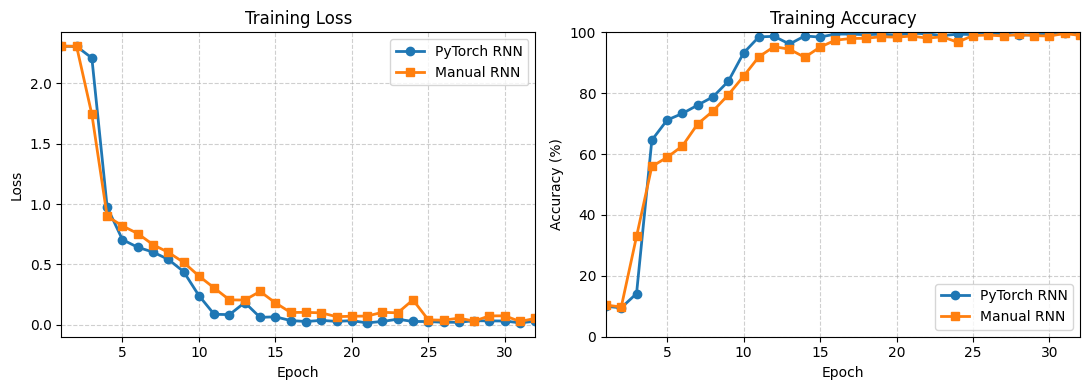

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

epochs_range = range(1, len(torch_train_losses) + 1)

# Loss
axes[0].plot(epochs_range, torch_train_losses, marker='o', linewidth=2, label="PyTorch RNN")
axes[0].plot(epochs_range, manual_train_losses, marker='s', linewidth=2, label="Manual RNN")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, [a * 100 for a in torch_train_accs], marker='o', linewidth=2, label="PyTorch RNN")
axes[1].plot(epochs_range, [a * 100 for a in manual_train_accs], marker='s', linewidth=2, label="Manual RNN")
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close(fig)

## Testing

In [26]:
torch_model.eval()
manual_model.eval()

with tc.no_grad():
    torch_loss_sum, torch_acc_sum = 0.0, 0.0
    manual_loss_sum, manual_acc_sum = 0.0, 0.0
    n = 0

    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # ----- PyTorch model -----
        torch_logits, _ = torch_model(x_batch)
        torch_logits_last = torch_logits[:, -1, :]

        torch_loss = loss_fn(torch_logits_last, y_batch)

        # ----- Manual model -----
        manual_logits, _ = manual_model(x_batch)
        manual_logits_last = manual_logits[:, -1, :]

        manual_loss = loss_fn(manual_logits_last, y_batch)

        # ----- Statistics -----
        B_curr = x_batch.size(0)

        torch_loss_sum += torch_loss.item() * B_curr
        torch_acc_sum  += batch_accuracy(torch_logits_last, y_batch) * B_curr

        manual_loss_sum += manual_loss.item() * B_curr
        manual_acc_sum  += batch_accuracy(manual_logits_last, y_batch) * B_curr

        n += B_curr

torch_test_loss = torch_loss_sum / n
torch_test_acc  = torch_acc_sum / n

manual_test_loss = manual_loss_sum / n
manual_test_acc  = manual_acc_sum / n

print(
    f"PyTorch model | test loss {torch_test_loss:.4f} | test acc {torch_test_acc*100:.2f}%\n"
    f"Manual model  | test loss {manual_test_loss:.4f} | test acc {manual_test_acc*100:.2f}%"
)

PyTorch model | test loss 0.0763 | test acc 98.14%
Manual model  | test loss 0.0140 | test acc 99.90%


## <u>Homework / Exploration (optional)</u>

### 1) Observe performance as the sequence length increases

Train the model for increasing sequence lengths, e.g.,: $T \in [10, 200]$. For example, evaluate several values across this range and plot loss and test accuracy vs sequence length. Questions to consider:

- At what sequence length does the model begin to fail?
- Does performance degrade gradually or suddenly?
- How does this relate to long-term dependencies?

---

### 2) Observe performance as noise increases

Increase the noise level applied to the sequence: $\text{noise_std} \in [0.0, 1.0]$. Train the model for several values across this range and plot loss and test accuracy vs noise level. Questions to consider:

- How robust is the model to noise?
- At what point does the useful signal become too weak for the RNN to recover?

---

### 3) Observe performance as hidden size changes

Vary the hidden dimension of the model, e.g., $d_h \in [4, 64]$. Train the model for several values within this range and plot loss and test accuracy vs hidden dimension. Questions to consider:

- What is the minimum hidden size that can reliably solve the task?
- Does increasing the hidden size always improve performance?

---

### 4) Observe performance as the key position changes

Instead of always placing the key at the first time step, try move it across the entire sequence. Train the model while placing the informative key at different positions and plot loss and test accuracy vs key position. Questions to consider:

- Is the model better at remembering information that appears later in the sequence?
- How strongly does performance depend on the distance between the signal and the prediction step?

### References

1) **Jeffrey L. Elman (1990)**  
   *Finding Structure in Time*  
   Cognitive Science, 14(2), 179–211.  
   https://papers.baulab.info/papers/Elman-1990.pdf

2) **Paul J. Werbos (1990)**  
   *Backpropagation Through Time: What It Does and How to Do It*  
   Proceedings of the IEEE, 78(10), 1550–1560.

3) **Yoshua Bengio, Patrice Simard, Paolo Frasconi (1994)**  
   *Learning Long-Term Dependencies with Gradient Descent is Difficult*  
   IEEE Transactions on Neural Networks, 5(2), 157–166.

4) **PyTorch Documentation — `torch.nn.RNN`**  
   Official implementation reference for vanilla recurrent neural networks.  
   https://pytorch.org/docs/stable/generated/torch.nn.RNN.html

5) **Calvin Feng — Machine Learning Notebook: Recurrent Neural Networks**  
   Introductory tutorial material used as supplementary inspiration for sequence processing examples.  
   https://calvinfeng.gitbook.io/machine-learning-notebook/supervised-learning/recurrent-neural-network/recurrent_neural_networks